# BioProtean Lab Workflow for spot detection of smFISH spots

1. Register raw smFISH images.
    Use the merfish3d-analysis package in the Qi2lab GitHub to perform image correction, deconvolution, local and global registration. 
2. Save registered, deconvolved zarr files from the qi2labdatastore as TIFF files.
3. Perform CellPose Segmentation on the registered polyDT channel. Save as TIFF.
4. Import the above data in BigFISH.
5. Perform spot detection in BigFISH.

## Step 5: Spot Detection

Spot detection with BIG FISH can be performed in 2D or 3D

In this notebook, we show examples of **mRNAs detection**. We use 3D images. Three main steps are developed:
- Detection of spots as local maximum.
- Decomposition of dense and bright regions by simulating as many new spots in these regions as possible.
- Detection of clustered spots.

In [11]:
import os
import numpy as np
import bigfish
import bigfish.stack as stack
import bigfish.detection as detection
import bigfish.multistack as multistack
import bigfish.plot as plot
import pandas as pd
import matplotlib.pyplot as plt
from skimage import segmentation
import matplotlib.patches as mpatches
from scipy import ndimage
from pathlib import Path
print("Big-FISH version: {0}".format(bigfish.__version__))

Big-FISH version: 0.6.2


In [12]:
# Change for your data
data = Path("/data/smFISH/20251028_bartelle_smFISH_mm_microglia_newbuffers")

input_dir = data / "qi2labdatastore" / "big_fish" / "tiffs"
output_dir = data / "qi2labdatastore" / "big_fish" / "results" / "one_tile_3D"
segmentation = data / "qi2labdatastore" / "big_fish" / "segmentation"

# Create output directory if needed
output_dir.mkdir(parents=True, exist_ok=True)


In [29]:
# Load in data 

# Bit 5 is Itgam
# These tiffs are the registered, deconvolved image
path = os.path.join(input_dir, "tile000bit005.ome.tiff")
rna = stack.read_image(path)
print("smfish channel")
print("\r shape: {0}".format(rna.shape))
print("\r dtype: {0}".format(rna.dtype))

# polyDT is our fiducial, or reference marker. This probe labels all polyadenylated RNA.
# Segmentation is performed on the 3D polyDT data using Cellpose
# We load in Cellpose masks to visualize the cell boundaries.
path = os.path.join(segmentation, "tile000round000corrected_polyDT.ome_cp_masks.tif")
polyDT_masks = stack.read_image(path)


print("polyDT channel")
print("\r shape: {0}".format(polyDT_masks.shape))
print("\r dtype: {0}".format(polyDT_masks.dtype), "\n")



smfish channel
 shape: (63, 2048, 2048)
 dtype: uint16
polyDT channel
 shape: (63, 2048, 2048)
 dtype: uint16 



## Spot detection

We assume **spot is a local maximum** in the smFISH channel. Three steps are required to detect them:
- Filter the smFISH channel to enhance the signal-to-noise ratio and denoise the image (`bigfish.stack.log_filter`).
- Detect the local maximum in the filtered image (`bigfish.detection.local_maximum_detection`).
- Remove the local maximum under a fixed threshold (`bigfish.detection.spots_thresholding`). To be robust, the thresholding should be applied on the filtered image. Thus, the threshold is set relatively to the filtered image values.
- If necessary, the optimal threshold can be estimated with `bigfish.detection.automated_threshold_setting` (applied on a filtered image).

All these steps are summarized in `bigfish.detection.detect_spots` that return the 3D coordinates of the detected spots.

In [5]:
# Detect spots in 3D 
# Detection in 3D takes ~2 minutes
# Does not use the polyDT channel
spots, threshold = detection.detect_spots(
    images=rna, 
    return_threshold=True, 
    voxel_size=(300, 103, 103),  # in nanometer (one value per dimension zyx)
    spot_radius=(350, 150, 150))  # in nanometer (one value per dimension zyx)

# The function detect_spots returns the coordinates (or list of coordinates) 
# of the spots with shape (nb_spots, 3) for 3D images.
print("detected spots")
print("\r shape: {0}".format(spots.shape))
print("\r dtype: {0}".format(spots.dtype))
print("\r threshold: {0}".format(threshold))

detected spots
 shape: (3080, 3)
 dtype: int64
 threshold: 484.0


In [7]:
spots_df = pd.DataFrame(spots, columns=["z", "y", "x"])
print(spots_df.head())

   z    y     x
0  7  857   104
1  7  932    86
2  8  118  1497
3  8  200   582
4  8  412   649


smfish channel (2D maximum projection)
 shape: (2048, 2048)
 dtype: uint16


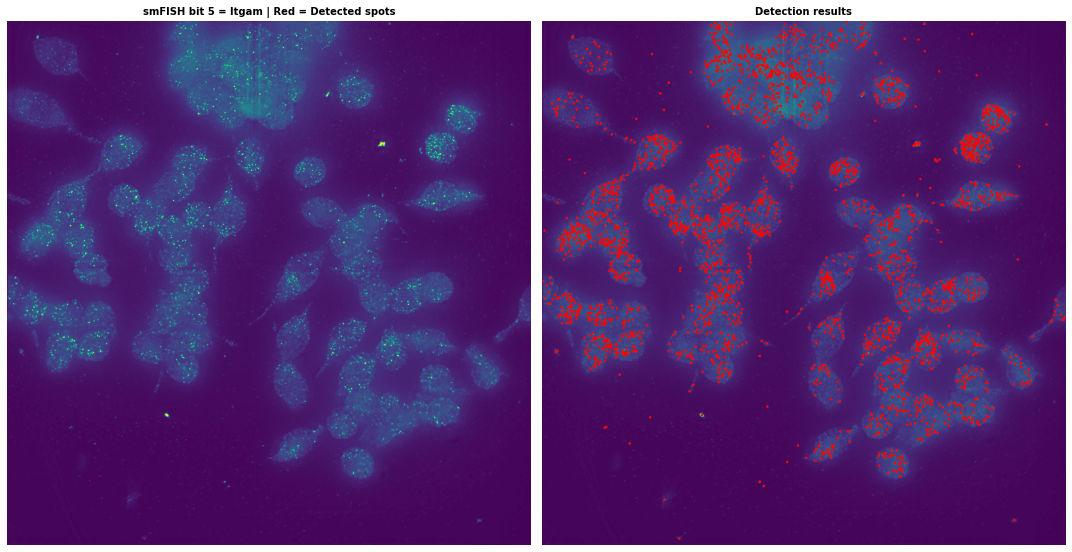

In [ ]:
# Create a maxiumum intensity projection of the RNA and polyDT channels for plotting purposes only 

rna_mip = stack.maximum_projection(rna)
print("smfish channel (2D maximum projection)")
print("\r shape: {0}".format(rna_mip.shape))
print("\r dtype: {0}".format(rna_mip.dtype))

plot.plot_detection(rna_mip, spots, contrast=True, title="smFISH bit 5 = Itgam | Red = Detected spots")

The automated spot detection method tries to find the optimal threshold to discriminate actual spots from noisy blobs. If we plot the number of the spots detected as a function of threshold level we observe an **elbow curve**. The selected threhold is the one located in the breaking point of the curve. This curve can be plotted with `bigfish.plot.plot_elbow`.

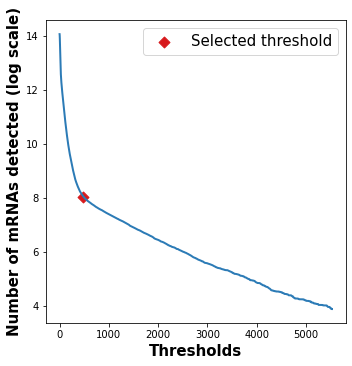

In [10]:
plot.plot_elbow(
    images=rna, 
    voxel_size=(300, 103, 103), 
    spot_radius=(350, 150, 150))

### (Optional) Spot Detection by setting your own spot radius and kernel size

Given the **voxel size** and the expected **spot radius** (in nanometer), the function `bigfish.detection.detect_spots` automatically estimates a **kernel size** for the LoG filtering and a **minimal distance** between two spots we want to be able to detect separately. It is still possible to set these parameters explicitly in order to fine-tune the detection. Internally, we approximate them as the spot radius in pixel with the function `bigfish.detection.get_object_radius_pixel`.

In [ ]:
spot_radius_px = detection.get_object_radius_pixel(
    voxel_size_nm=(300, 103, 103), 
    object_radius_nm=(350, 150, 150), 
    ndim=3)
print("spot radius (z axis): {:0.3f} pixels".format(spot_radius_px[0]))
print("spot radius (yx plan): {:0.3f} pixels".format(spot_radius_px[-1]))

spot radius (z axis): 1.167 pixels
spot radius (yx plan): 1.456 pixels


In [ ]:
spots, threshold = detection.detect_spots(
    images=rna, 
    return_threshold=True, 
    log_kernel_size=(1.167, 1.456, 1.456),
    minimum_distance=(1.167, 1.456, 1.456))
print("detected spots")
print("\r shape: {0}".format(spots.shape))
print("\r dtype: {0}".format(spots.dtype))
print("\r threshold: {0}".format(threshold))

detected spots
 shape: (3080, 3)
 dtype: int64
 threshold: 484.0


__Note:__ What we call spot radius in this notebook can be understood as its **Point Spread Function (PSF)**. For simplicity sake, this PSF is modelled as a 2D or 3D gaussian.

## Dense region decomposition

The detection of local maximum is not able to detect individual spots clustered in a dense and bright region. We try to **decompose these regions by simulating as many spots as possible until we match the original region intensity**. Our current steps are:
- Denoise the smFISH channel by estimating then removing its background (`bigfish.stack.remove_background_gaussian`).
- Build a reference median spot from the individual predetected spots (`bigfish.detection.build_reference_spot`).
- Fit a gaussian signal on the reference spot (`bigfish.detection.modelize_spot`).
- Detect the candidate dense regions in the denoised image - large regions brighter than the reference spot (`bigfish.detection.get_dense_region`).
- Use the fitted gaussian signal to fill as many spots in the candidate regions as possible (`bigfish.detection.simulate_gaussian_mixture`).

All these steps are summarized in `bigfish.detection.decompose_dense` that return the 2D or 3D coordinates of the detected spots outside and inside a decomposed region, additional information about the regions themself and an image of the reference spot estimated.

In [15]:
spots_post_decomposition, dense_regions, reference_spot = detection.decompose_dense(
    image=rna, 
    spots=spots, 
    voxel_size=(300, 103, 103), 
    spot_radius=(350, 150, 150), 
    alpha=0.7,  # alpha impacts the number of spots per candidate region
    beta=1,  # beta impacts the number of candidate regions to decompose
    gamma=5)  # gamma the filtering step to denoise the image
print("detected spots before decomposition")
print("\r shape: {0}".format(spots.shape))
print("\r dtype: {0}".format(spots.dtype), "\n")
print("detected spots after decomposition")
print("\r shape: {0}".format(spots_post_decomposition.shape))
print("\r dtype: {0}".format(spots_post_decomposition.dtype))

detected spots before decomposition
 shape: (3080, 3)
 dtype: int64 

detected spots after decomposition
 shape: (4064, 3)
 dtype: int64


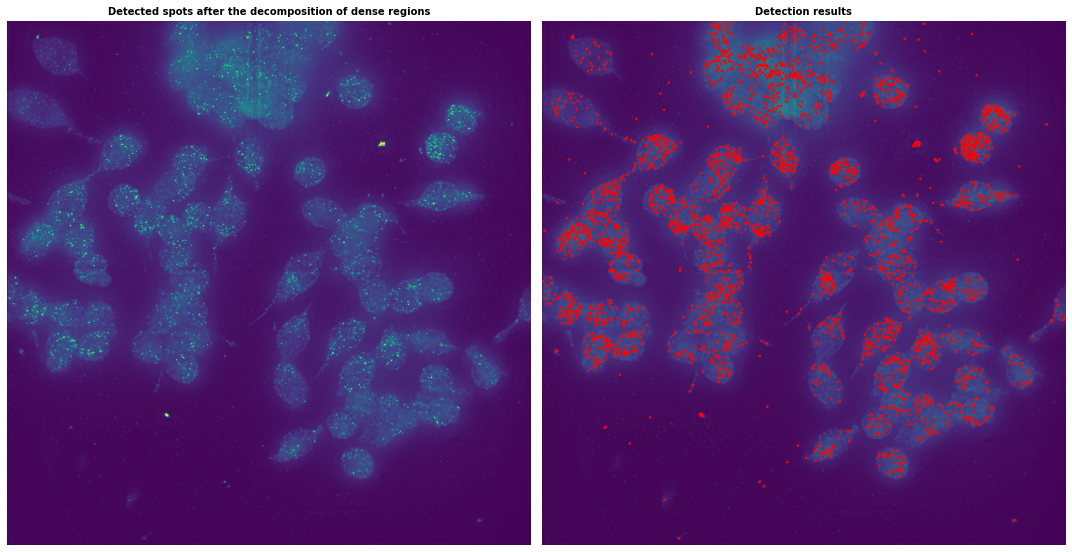

In [16]:
plot.plot_detection(rna_mip, spots_post_decomposition, contrast=True, title="Detected spots after the decomposition of dense regions")

## Clusters detection
Two spots are considered connected if they localized within a specific radius (in nanometer). Above a minimum number of connected spots, a cluster can be defined. This detection can be computed with `bigfish.detection.detect_clusters`.

In [17]:
spots_post_clustering, clusters = detection.detect_clusters(
    spots=spots_post_decomposition, 
    voxel_size=(300, 103, 103), 
    radius=350, 
    nb_min_spots=4)
print("detected spots after clustering")
print("\r shape: {0}".format(spots_post_clustering.shape))
print("\r dtype: {0}".format(spots_post_clustering.dtype), "\n")
print("detected clusters")
print("\r shape: {0}".format(clusters.shape))
print("\r dtype: {0}".format(clusters.dtype))

detected spots after clustering
 shape: (4064, 4)
 dtype: int64 

detected clusters
 shape: (57, 5)
 dtype: int64


The function detect_clusters returns the following:

spots_post_clustering contains the coordinates of the detected spots with shape (nb_spots, 4) or (nb_spots, 3). One coordinate per dimension (z,y,x or y,x coordinates) plus the index of the cluster assigned to the spot. If no cluster was assigned, value is -1.

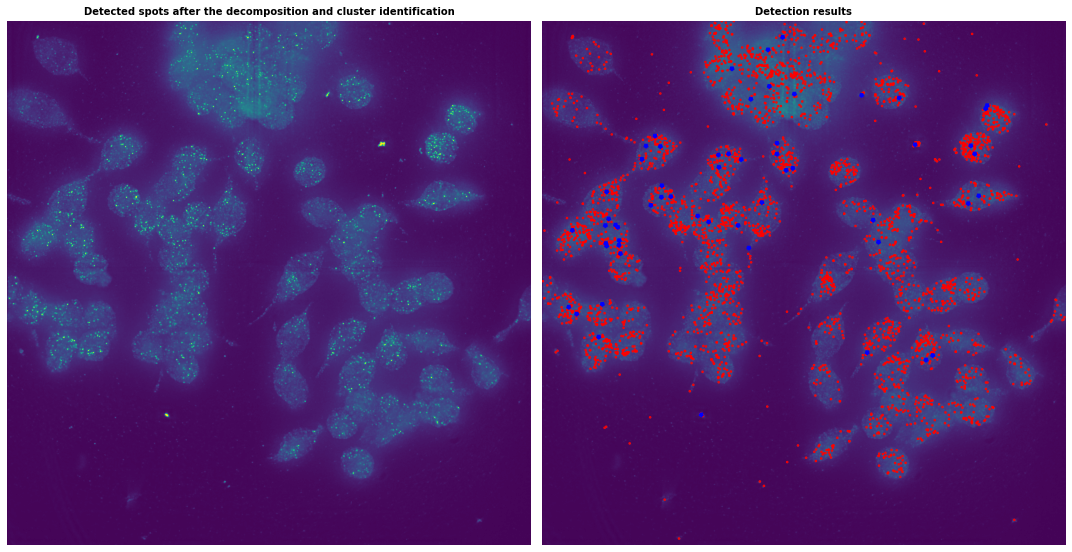

In [19]:
# plot
# The spots are in red, the clusters are in blue
plot.plot_detection(rna_mip, 
                    spots=[spots_post_decomposition, clusters[:, :3]], 
                    shape=["circle", "polygon"], 
                    radius=[3, 6], 
                    color=["red", "blue"],
                    linewidth=[1, 2], 
                    fill=[False, True], 
                    contrast=True,
                    title='Detected spots after the decomposition and cluster identification',
                    )

## Save results

Spots and foci coordinates can be saved in **npy files** (numpy dedicated format) or **csv files** using functions `bigfish.stack.save_array` and `bigfish.stack.save_data_to_csv` respectively.

In [20]:
# save in npy files
path = os.path.join(output_dir, "spots.npy")
stack.save_array(spots_post_clustering, path)
path = os.path.join(output_dir, "clusters.npy")
stack.save_array(clusters, path)


# save in csv files
# The header of the csv file is y, x, cluster identity #
spots_df = pd.DataFrame(spots_post_clustering, columns=['z', 'y', 'x', 'cluster number'])
path = os.path.join(output_dir, "spots.csv")
stack.save_data_to_csv(spots_df, path, delimiter=',')
path = os.path.join(output_dir, "clusters.csv")
stack.save_data_to_csv(clusters, path, delimiter=',')

## Step 6: Plot Results

From Notebook 6 - Extract cell level results.ipynb

In [35]:
# Load a maxiumum intensity projection of the polyDT channel for plotting purposes only 
path = os.path.join(input_dir, "max_projected_tile000round000corrected_polyDT.ome.tiff")
polyDT_mip = stack.read_image(path)
print("polyDT channel")
print("\r shape: {0}".format(polyDT_mip.shape))
print("\r dtype: {0}".format(polyDT_mip.dtype), "\n")

# max project the masks
polyDT_masks_mip = stack.maximum_projection(polyDT_masks)

# stretch the contrast otherwise the spots will be dim and hard to see
image_contrasted = stack.rescale(rna_mip, channel_to_stretch=0)

polyDT channel
 shape: (2048, 2048)
 dtype: uint16 



Read in segmentation and detection results

In [ ]:
# detected spots
path = os.path.join(output_dir, "spots.csv")
spots = stack.read_array_from_csv(path, dtype=np.int64, delimiter=',', skiprows=1)
print("detected spots")
print("\r shape: {0}".format(spots.shape))
print("\r dtype: {0}".format(spots.dtype), "\n")

# detected foci
path = os.path.join(output_dir, "clusters.csv")
clusters = stack.read_array_from_csv(path, dtype=np.int64, delimiter=',')
print("detected clusters")
print("\r shape: {0}".format(clusters.shape))
print("\r dtype: {0}".format(clusters.dtype))

detected spots
 shape: (4064, 4)
 dtype: int64 

detected clusters
 shape: (57, 5)
 dtype: int64


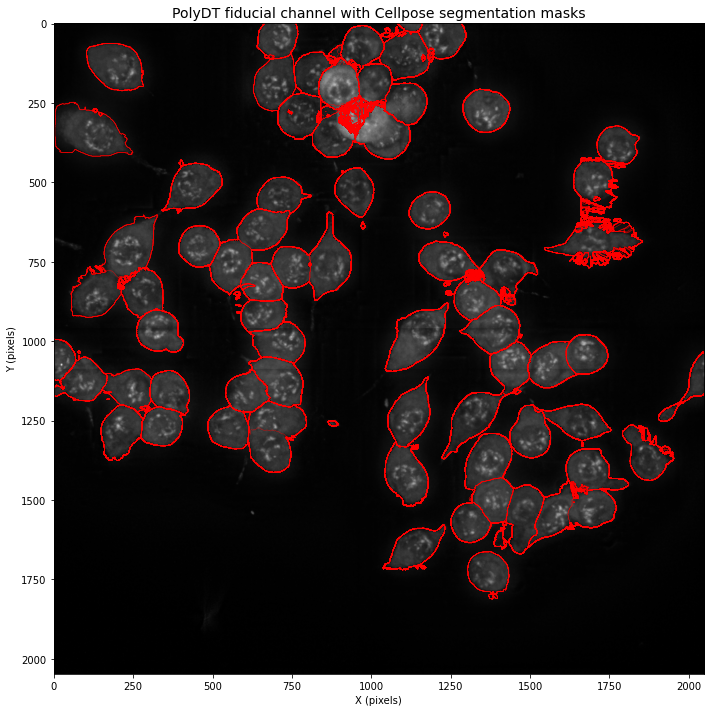

In [ ]:
# visuzalize the Cellpose segmentations on top of the polyDT channel
# Note: the 3D masks look odd

# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 10))

# Display the polyDT_mip image
ax.imshow(polyDT_mip, cmap='gray')

# Overlay the cellpose segmentation masks as outlines using contour
ax.contour(polyDT_masks_mip, levels=np.unique(polyDT_masks_mip)[1:], colors='red', linewidths=0.5, alpha=0.7)

ax.set_title('PolyDT fiducial channel with Cellpose segmentation masks', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')

plt.tight_layout()
plt.show()

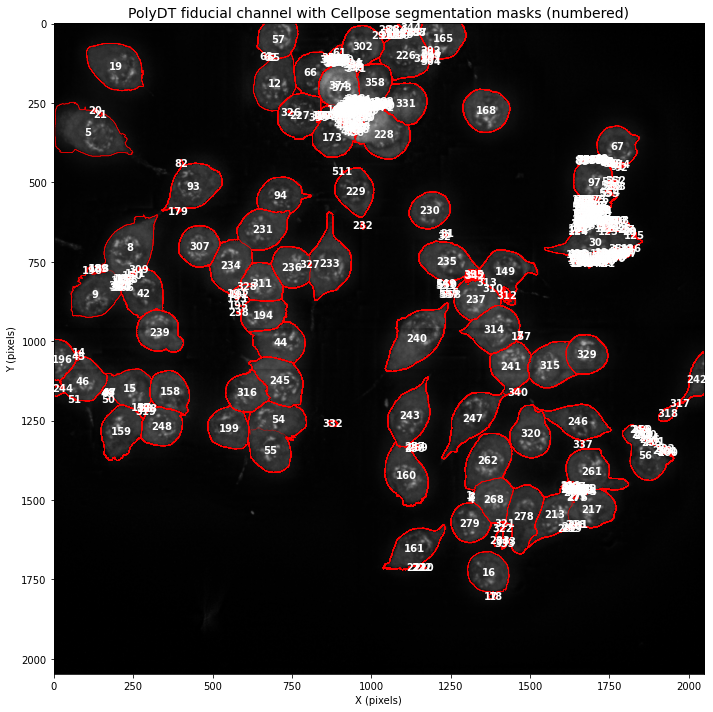

In [37]:
# create the figure with cells numbered

# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 10))

# Display the polyDT_mip image
ax.imshow(polyDT_mip, cmap='gray')

# Overlay the cellpose segmentation masks as outlines using contour
ax.contour(polyDT_masks_mip, levels=np.unique(polyDT_masks_mip)[1:], colors='red', linewidths=0.5, alpha=0.7)

# Add cell numbers at the centroid of each cell
cell_ids = np.unique(polyDT_masks_mip)
cell_ids = cell_ids[cell_ids != 0]  # Remove background label (0)

for cell_id in cell_ids:
    # Find centroid of the cell
    cell_mask = polyDT_masks_mip == cell_id
    coords = np.where(cell_mask)
    centroid_y = np.mean(coords[0])
    centroid_x = np.mean(coords[1])
    
    # Add text label at centroid
    ax.text(centroid_x, centroid_y, str(int(cell_id)), 
            color='white', fontsize=10, fontweight='bold',
            ha='center', va='center',
            )

ax.set_title('PolyDT fiducial channel with Cellpose segmentation masks (numbered)', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')

plt.tight_layout()
plt.show()

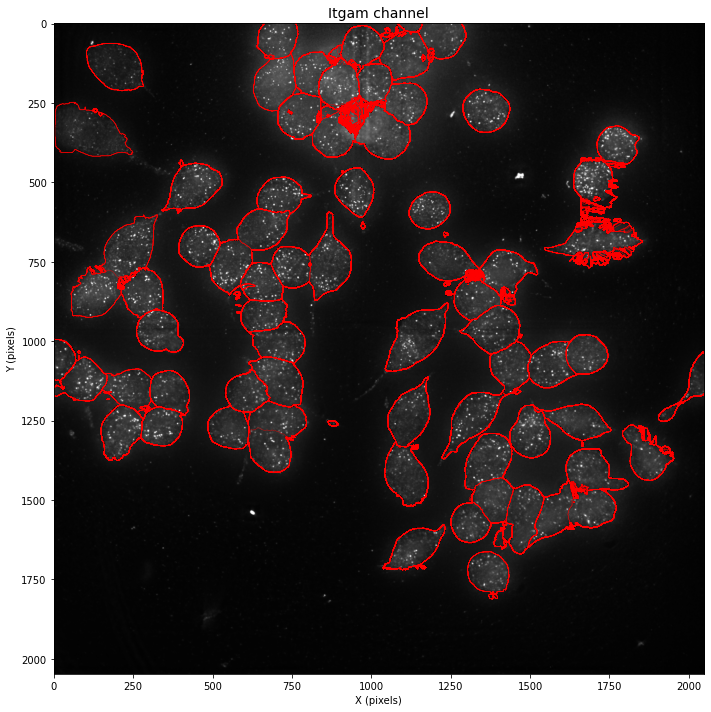

In [40]:
# visuzalize the Cellpose segmentations on top of the Itgam channel

# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 10))

# Display the Itgam channel image
ax.imshow(image_contrasted, cmap='gray')

# Overlay the cellpose segmentation masks as outlines using contour
ax.contour(polyDT_masks_mip, levels=np.unique(polyDT_masks_mip)[1:], colors='red', linewidths=0.5, alpha=0.7)

ax.set_title('Itgam channel', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')

plt.tight_layout()
plt.show()

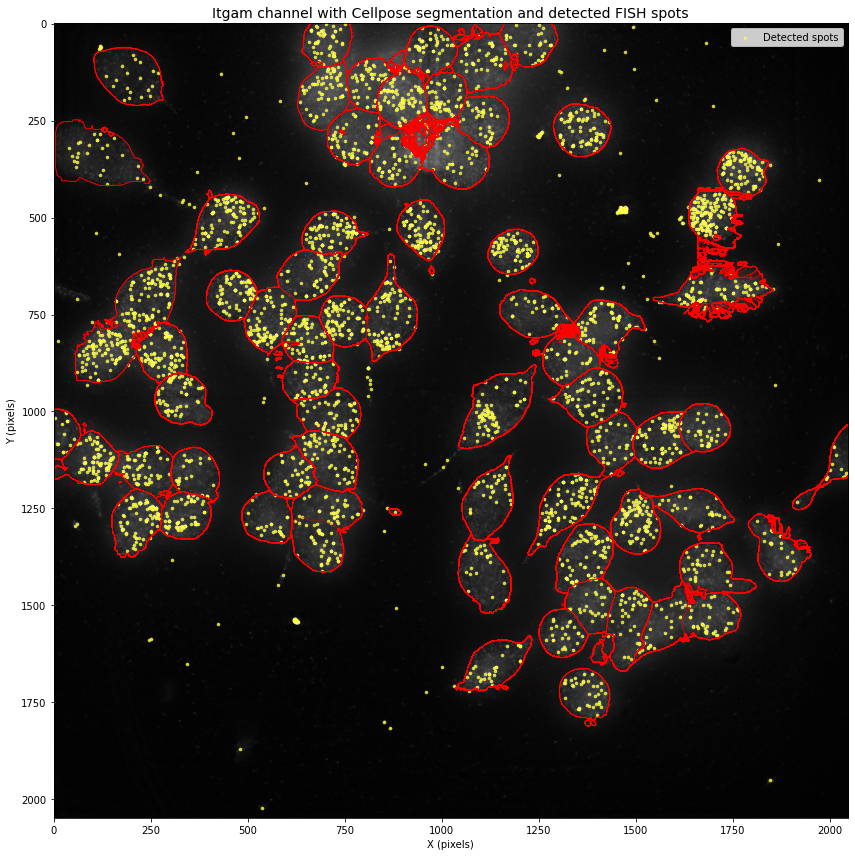

In [42]:
# visualize the RNA channel with Cellpose segmentations and detected FISH spots

# Create figure and axes
fig, ax = plt.subplots(figsize=(14, 12))

# Display the contrast-enhanced Itgam channel image in grayscale
ax.imshow(image_contrasted, cmap='gray')

# Overlay the cellpose segmentation masks as outlines using contour
ax.contour(polyDT_masks_mip, levels=np.unique(polyDT_masks_mip)[1:], colors='red', linewidths=0.5, alpha=0.7)

# Overlay detected FISH spots
# spots has shape (nb_spots, 3) or (nb_spots, 2), for 3D or 2D images respectively.
# with the columns following the format (y, x) for 2D
spot_y = spots[:, 1]
spot_x = spots[:, 2]

# Plot detected spots as yellow circles (smaller size)
ax.scatter(spot_x, spot_y, c='yellow', s=10, marker='o', 
           edgecolors='white', linewidth=0.3, alpha=0.8, label='Detected spots')

ax.set_title('Itgam channel with Cellpose segmentation and detected FISH spots', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

Now, add the code to create the dataframe of spots. This is a work in progress